In [42]:
import requests
import torch
import os
import fastf1
from fastf1 import plotting
from fastf1.ergast import Ergast
from datetime import datetime, timedelta
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [43]:
import requests
import pandas as pd
import time

def extract_results_to_csv(start_year, end_year):
    all_results = []
    base_url = "http://api.jolpi.ca/ergast/f1/{year}.json"
    results_url_template = "http://api.jolpi.ca/ergast/f1/{year}/{round}/results.json"
    sprint_url_template = "http://api.jolpi.ca/ergast/f1/{year}/{round}/sprint.json"
    
    for year in range(start_year, end_year + 1):
        print(f"\n--- Processing Season: {year} ---")
        
        try:
            # Get the schedule for the year
            schedule_url = base_url.format(year=year)
            schedule_response = requests.get(schedule_url)
            schedule_response.raise_for_status()
            schedule = schedule_response.json()['MRData']['RaceTable']['Races']
            print(f"Successfully fetched schedule for {year}.")

            for race in schedule:
                round_num = race['round']
                race_name = race['raceName']
                race_date = race['date']
                circuit_name = race['Circuit']['circuitName']
                
                # ===== FETCH SPRINT RESULTS FIRST (if available) =====
                print(f"  Checking for Sprint: {race_name} (Round {round_num})...")
                sprint_url = sprint_url_template.format(year=year, round=round_num)
                
                try:
                    sprint_response = requests.get(sprint_url)
                    sprint_response.raise_for_status()
                    sprint_data = sprint_response.json()
                    
                    if sprint_data['MRData']['RaceTable']['Races']:
                        sprint_results = sprint_data['MRData']['RaceTable']['Races'][0].get('SprintResults', [])
                        
                        if sprint_results:
                            print(f"    ✓ Sprint race found!")
                            for res in sprint_results:
                                all_results.append({
                                    'season_year': year,
                                    'race_round_number': int(round_num),
                                    'race_name': race_name,
                                    'race_date': race_date,
                                    'circuit_name': circuit_name,
                                    'session_type': 'Sprint',  # ← NEW FIELD
                                    'driver_name': f"{res['Driver']['givenName']} {res['Driver']['familyName']}",
                                    'driver_nationality': res['Driver']['nationality'],
                                    'constructor_name': res['Constructor']['name'],
                                    'grid_position': int(res['grid']) if int(res['grid']) > 0 else 20,
                                    'final_position': int(res['position']),
                                    'points': float(res.get('points', 0)),
                                    'laps_completed': int(res.get('laps', 0)),
                                    'race_time': res.get('Time', {}).get('time', 'N/A'),
                                    'fastest_lap': res.get('FastestLap', {}).get('Time', {}).get('time', 'N/A'),
                                    'status': res['status']
                                })
                        else:
                            print(f"    ⊗ No sprint race at this event")
                except requests.exceptions.RequestException:
                    print(f"    ⊗ No sprint race at this event")
                
                # ===== FETCH MAIN RACE RESULTS =====
                print(f"  Processing Main Race: {race_name} (Round {round_num})...")
                results_url = results_url_template.format(year=year, round=round_num)
                results_response = requests.get(results_url)
                results_response.raise_for_status()

                results_data = results_response.json()
                if results_data['MRData']['RaceTable']['Races']:
                    results = results_data['MRData']['RaceTable']['Races'][0]['Results']
                    
                    for res in results:
                        all_results.append({
                            'season_year': year,
                            'race_round_number': int(round_num),
                            'race_name': race_name,
                            'race_date': race_date,
                            'circuit_name': circuit_name,
                            'session_type': 'Race',  # ← NEW FIELD
                            'driver_name': f"{res['Driver']['givenName']} {res['Driver']['familyName']}",
                            'driver_nationality': res['Driver']['nationality'],
                            'constructor_name': res['Constructor']['name'],
                            'grid_position': int(res['grid']) if int(res['grid']) > 0 else 20,
                            'final_position': int(res['position']),
                            'points': float(res.get('points', 0)),
                            'laps_completed': int(res.get('laps', 0)),
                            'race_time': res.get('Time', {}).get('time', 'N/A'),
                            'fastest_lap': res.get('FastestLap', {}).get('Time', {}).get('time', 'N/A'),
                            'status': res['status']
                        })
                
                print(f"    ✓ Processed {race_name}")
                time.sleep(0.5)  # Rate limiting - be nice to the API
             
        except requests.exceptions.RequestException as e:
            print(f"✗ Error processing year {year}: {e}")
            continue

    if all_results:
        df = pd.DataFrame(all_results)
        df.to_csv('f1_results_2025_with_sprints.csv', index=False)
        print(f"\n✅ Data extraction complete! Saved {len(all_results)} records")
        print(f"   - Total races and sprints combined")
        print(f"Columns included: {list(df.columns)}")
        
        # Summary stats
        sprint_count = df[df['session_type'] == 'Sprint'].shape[0]
        race_count = df[df['session_type'] == 'Race'].shape[0]
        print(f"\n📊 Summary:")
        print(f"   Sprint results: {sprint_count}")
        print(f"   Race results: {race_count}")
    else:
        print("\n❌ No data was extracted. Please check the error messages.")

# Extract data
extract_results_to_csv(2025, 2025)



--- Processing Season: 2025 ---
Successfully fetched schedule for 2025.
  Checking for Sprint: Australian Grand Prix (Round 1)...
  Processing Main Race: Australian Grand Prix (Round 1)...
    ✓ Processed Australian Grand Prix
  Checking for Sprint: Chinese Grand Prix (Round 2)...
    ✓ Sprint race found!
  Processing Main Race: Chinese Grand Prix (Round 2)...
    ✓ Processed Chinese Grand Prix
  Checking for Sprint: Japanese Grand Prix (Round 3)...
  Processing Main Race: Japanese Grand Prix (Round 3)...
    ✓ Processed Japanese Grand Prix
  Checking for Sprint: Bahrain Grand Prix (Round 4)...
  Processing Main Race: Bahrain Grand Prix (Round 4)...
    ✓ Processed Bahrain Grand Prix
  Checking for Sprint: Saudi Arabian Grand Prix (Round 5)...
  Processing Main Race: Saudi Arabian Grand Prix (Round 5)...
    ✓ Processed Saudi Arabian Grand Prix
  Checking for Sprint: Miami Grand Prix (Round 6)...
    ✓ Sprint race found!
  Processing Main Race: Miami Grand Prix (Round 6)...
    ✓ Proc

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [84]:

df = pd.read_csv('f1_results_2025_with_sprints.csv')


In [85]:
df.shape

(419, 16)

In [86]:
df_sprint.head()

,season_year,race_round_number,race_name,race_date,circuit_name,session_type,driver_name,driver_nationality,constructor_name,grid_position,final_position,points,laps_completed,race_time,fastest_lap,status
0,2025,1,Australian Grand Prix,2025-03-16,Albert Park Grand Prix Circuit,Race,Lando Norris,British,McLaren,1,1,25.0,57,1:42:06.304,1:22.167,Finished
1,2025,1,Australian Grand Prix,2025-03-16,Albert Park Grand Prix Circuit,Race,Max Verstappen,Dutch,Red Bull,3,2,18.0,57,+0.895,1:23.081,Finished
2,2025,1,Australian Grand Prix,2025-03-16,Albert Park Grand Prix Circuit,Race,George Russell,British,Mercedes,4,3,15.0,57,+8.481,1:25.065,Finished
3,2025,1,Australian Grand Prix,2025-03-16,Albert Park Grand Prix Circuit,Race,Andrea Kimi Antonelli,Italian,Mercedes,16,4,12.0,57,+10.135,1:24.901,Finished
4,2025,1,Australian Grand Prix,2025-03-16,Albert Park Grand Prix Circuit,Race,Alexander Albon,Thai,Williams,6,5,10.0,57,+12.773,1:24.597,Finished


In [87]:
df.describe()

,season_year,race_round_number,grid_position,final_position,points,laps_completed
count,419.0,419.000000,419.000000,419.000000,419.000000,419.000000
mean,2025.0,9.143198,10.477327,10.477327,4.596659,49.536993
std,0.0,5.188183,5.761308,5.761308,6.823271,20.614262
min,2025.0,1.000000,1.000000,1.000000,0.000000,0.000000
25%,2025.0,5.000000,5.500000,5.500000,0.000000,44.000000
50%,2025.0,9.000000,10.000000,10.000000,0.000000,53.000000
75%,2025.0,13.000000,15.000000,15.000000,8.000000,65.000000
max,2025.0,18.000000,20.000000,20.000000,25.000000,78.000000


In [88]:
df.isnull().sum()

season_year            0
race_round_number      0
race_name              0
race_date              0
circuit_name           0
session_type           0
driver_name            0
driver_nationality     0
constructor_name       0
grid_position          0
final_position         0
points                 0
laps_completed         0
race_time             45
fastest_lap           18
status                 0
dtype: int64

In [89]:
df.columns

Index(['season_year', 'race_round_number', 'race_name', 'race_date',
       'circuit_name', 'session_type', 'driver_name', 'driver_nationality',
       'constructor_name', 'grid_position', 'final_position', 'points',
       'laps_completed', 'race_time', 'fastest_lap', 'status'],
      dtype='object')

In [90]:
df.shape

(419, 16)

In [91]:
df['season_year'].nunique()

1

In [92]:

print("The number of unique drivers is:", df['driver_name'].nunique())
print("The number of unique constructors is:", df['constructor_name'].nunique())
print("The number of unique circuits is:", df['circuit_name'].nunique())


The number of unique drivers is: 21
The number of unique constructors is: 10
The number of unique circuits is: 18


In [93]:
print("Races per season:")
df.groupby('season_year')['race_round_number'].nunique()

Races per season:


season_year
2025    18
Name: race_round_number, dtype: int64

## Winner Analysis

In [94]:
# Most successful drivers (race wins)
race_winners = df[df['final_position'] == 1]['driver_name'].value_counts()
race_winners

driver_name
Oscar Piastri     7
Lando Norris      6
Max Verstappen    5
George Russell    2
Lewis Hamilton    1
Name: count, dtype: int64

In [95]:
constructor_wins = df[df['final_position'] == 1]['constructor_name'].value_counts()
print(f"\nTop Constructor Wins:")
print(constructor_wins.head(8))


Top Constructor Wins:
constructor_name
McLaren     13
Red Bull     5
Mercedes     2
Ferrari      1
Name: count, dtype: int64


## Most Successful Qualifying

In [96]:
print("Wins from each grid position:")
df[df['final_position'] == 1]['grid_position'].value_counts().sort_index()

Wins from each grid position:


grid_position
1    13
2     4
3     3
4     1
Name: count, dtype: int64

In [97]:
print("Pole Position Results:")
df[df['grid_position'] == 1]['final_position'].value_counts().sort_index()

Pole Position Results:


final_position
1    13
2     3
3     1
4     2
5     1
7     1
Name: count, dtype: int64

In [98]:
print(f"\nAverage finish position by starting grid:")
df.groupby('grid_position')['final_position'].mean()


Average finish position by starting grid:


grid_position
1      2.000000
2      3.190476
3      3.380952
4      4.666667
5      6.285714
6      9.952381
7      8.571429
8     11.190476
9     11.809524
10    10.333333
11    12.571429
12    12.952381
13    12.904762
14    14.000000
15    13.428571
16    15.047619
17    14.619048
18    14.285714
19    14.476190
20    14.050000
Name: final_position, dtype: float64

In [99]:
df['status'].value_counts()

status
Finished         300
Lapped            72
Retired           40
Disqualified       4
Did not start      3
Name: count, dtype: int64

## Fastest Lap of Each  CIRCUIT

In [100]:
def get_fastest_laps_by_circuit(csv_file):
    """
    Extract the fastest lap time for each circuit from F1 race data
    """
    # Load data
    df1 = pd.read_csv(csv_file)
    
    # Convert lap times to seconds for proper comparison
    def parse_laptime(time_str):
        if pd.isna(time_str) or time_str == 'N/A':
            return np.nan
        try:
            if ':' in str(time_str):
                min_sec = str(time_str).split(':')
                return int(min_sec[0]) * 60 + float(min_sec[1])
            return float(time_str)
        except:
            return np.nan
    
    df1['lap_seconds'] = df1['fastest_lap'].apply(parse_laptime)
    df_valid = df1.dropna(subset=['lap_seconds'])
    
    # Get fastest lap per circuit
    fastest_by_circuit = df_valid.loc[df_valid.groupby('circuit_name')['lap_seconds'].idxmin()]
    
    # Create results
    results = fastest_by_circuit.sort_values('circuit_name')[
        ['circuit_name', 'fastest_lap', 'driver_name', 'constructor_name', 'season_year', 'race_name']
    ].copy()
    
    return results

# Execute the function
fastest_laps = get_fastest_laps_by_circuit('f1_results_2025.csv')

# Display results
print("🏎️  FASTEST LAP RECORDS BY CIRCUIT (2019-2025)")
print("=" * 70)

for _, record in fastest_laps.iterrows():
    print(f"🏁 {record['circuit_name']}")
    print(f"   ⏱️  {record['fastest_lap']}")
    print(f"   🏆 {record['driver_name']} ({record['constructor_name']})")
    print(f"   📅 {record['season_year']} {record['race_name']}")
    print()


🏎️  FASTEST LAP RECORDS BY CIRCUIT (2019-2025)
🏁 Albert Park Grand Prix Circuit
   ⏱️  1:22.167
   🏆 Lando Norris (McLaren)
   📅 2025 Australian Grand Prix

🏁 Autodromo Enzo e Dino Ferrari
   ⏱️  1:17.988
   🏆 Max Verstappen (Red Bull)
   📅 2025 Emilia Romagna Grand Prix

🏁 Autodromo Nazionale di Monza
   ⏱️  1:20.901
   🏆 Lando Norris (McLaren)
   📅 2025 Italian Grand Prix

🏁 Bahrain International Circuit
   ⏱️  1:35.140
   🏆 Oscar Piastri (McLaren)
   📅 2025 Bahrain Grand Prix

🏁 Baku City Circuit
   ⏱️  1:43.388
   🏆 Max Verstappen (Red Bull)
   📅 2025 Azerbaijan Grand Prix

🏁 Circuit Gilles Villeneuve
   ⏱️  1:14.119
   🏆 George Russell (Mercedes)
   📅 2025 Canadian Grand Prix

🏁 Circuit Park Zandvoort
   ⏱️  1:12.271
   🏆 Oscar Piastri (McLaren)
   📅 2025 Dutch Grand Prix

🏁 Circuit de Barcelona-Catalunya
   ⏱️  1:15.743
   🏆 Oscar Piastri (McLaren)
   📅 2025 Spanish Grand Prix

🏁 Circuit de Monaco
   ⏱️  1:13.221
   🏆 Lando Norris (McLaren)
   📅 2025 Monaco Grand Prix

🏁 Circuit 

In [101]:
df.head()

,season_year,race_round_number,race_name,race_date,circuit_name,session_type,driver_name,driver_nationality,constructor_name,grid_position,final_position,points,laps_completed,race_time,fastest_lap,status
0,2025,1,Australian Grand Prix,2025-03-16,Albert Park Grand Prix Circuit,Race,Lando Norris,British,McLaren,1,1,25.0,57,1:42:06.304,1:22.167,Finished
1,2025,1,Australian Grand Prix,2025-03-16,Albert Park Grand Prix Circuit,Race,Max Verstappen,Dutch,Red Bull,3,2,18.0,57,+0.895,1:23.081,Finished
2,2025,1,Australian Grand Prix,2025-03-16,Albert Park Grand Prix Circuit,Race,George Russell,British,Mercedes,4,3,15.0,57,+8.481,1:25.065,Finished
3,2025,1,Australian Grand Prix,2025-03-16,Albert Park Grand Prix Circuit,Race,Andrea Kimi Antonelli,Italian,Mercedes,16,4,12.0,57,+10.135,1:24.901,Finished
4,2025,1,Australian Grand Prix,2025-03-16,Albert Park Grand Prix Circuit,Race,Alexander Albon,Thai,Williams,6,5,10.0,57,+12.773,1:24.597,Finished


In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 419 entries, 0 to 418
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   season_year         419 non-null    int64  
 1   race_round_number   419 non-null    int64  
 2   race_name           419 non-null    object 
 3   race_date           419 non-null    object 
 4   circuit_name        419 non-null    object 
 5   session_type        419 non-null    object 
 6   driver_name         419 non-null    object 
 7   driver_nationality  419 non-null    object 
 8   constructor_name    419 non-null    object 
 9   grid_position       419 non-null    int64  
 10  final_position      419 non-null    int64  
 11  points              419 non-null    float64
 12  laps_completed      419 non-null    int64  
 13  race_time           374 non-null    object 
 14  fastest_lap         401 non-null    object 
 15  status              419 non-null    object 
dtypes: float

## Visualisation

In [103]:
race_winners

driver_name
Oscar Piastri     7
Lando Norris      6
Max Verstappen    5
George Russell    2
Lewis Hamilton    1
Name: count, dtype: int64

In [104]:
plt.figure(figsize=(12, 6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

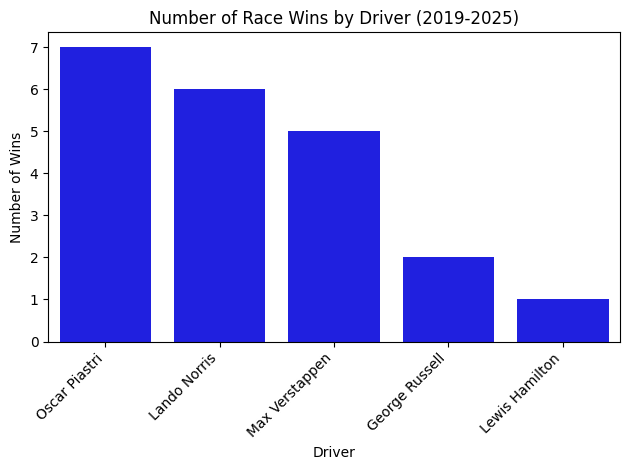

In [105]:
sns.barplot(x=race_winners.index, y=race_winners.values, color='b')
plt.xticks(rotation=45, ha='right')
plt.title('Number of Race Wins by Driver (2019-2025)')
plt.xlabel('Driver')
plt.ylabel('Number of Wins')
plt.tight_layout()

In [106]:
constructor_wins

constructor_name
McLaren     13
Red Bull     5
Mercedes     2
Ferrari      1
Name: count, dtype: int64

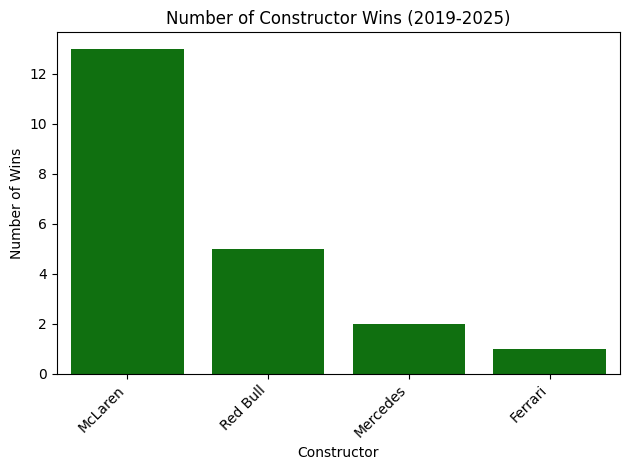

In [107]:
sns.barplot(x=constructor_wins.index, y=constructor_wins.values, color='g')
plt.xticks(rotation=45, ha='right')
plt.title('Number of Constructor Wins (2019-2025)')
plt.xlabel('Constructor')
plt.ylabel('Number of Wins')
plt.tight_layout()

In [108]:
podium_finishers = df[df['final_position'] <= 3]['driver_name'].value_counts()
podium_finishers

driver_name
Oscar Piastri            17
Lando Norris             16
Max Verstappen           11
George Russell            8
Charles Leclerc           5
Lewis Hamilton            2
Andrea Kimi Antonelli     1
Nico Hülkenberg           1
Isack Hadjar              1
Carlos Sainz              1
Name: count, dtype: int64

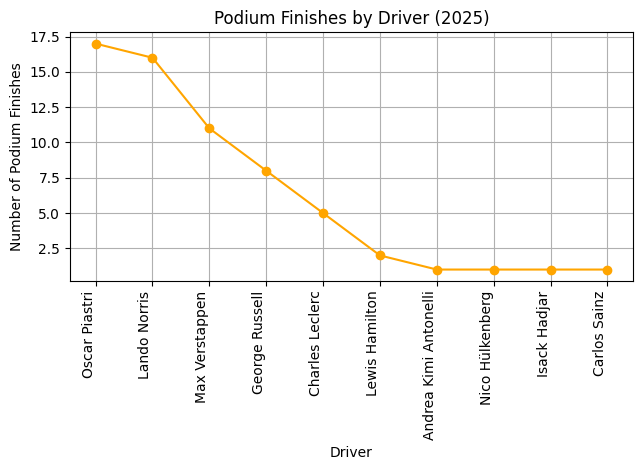

In [109]:
plt.plot(podium_finishers.index, podium_finishers.values, marker='o', linestyle='-', color='orange')
plt.xticks(rotation=90, ha='right')
plt.xlabel('Driver')
plt.ylabel('Number of Podium Finishes')
plt.title('Podium Finishes by Driver (2025)')
plt.grid(True)
plt.tight_layout()

<Figure size 1200x600 with 0 Axes>

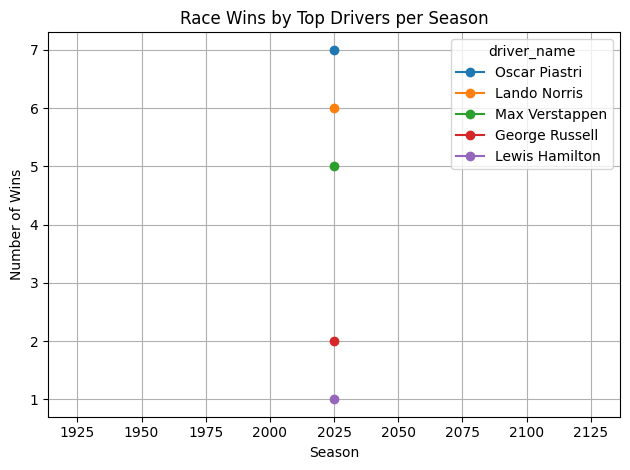

In [110]:
plt.figure(figsize=(12, 6))
top_drivers = race_winners.nlargest(8).index
season_wins = df[df['final_position'] == 1].groupby(['season_year', 'driver_name']).size().unstack()
season_wins[top_drivers].plot(marker='o')
plt.title('Race Wins by Top Drivers per Season')
plt.xlabel('Season')
plt.ylabel('Number of Wins')
plt.grid(True)
plt.tight_layout()
plt.show()

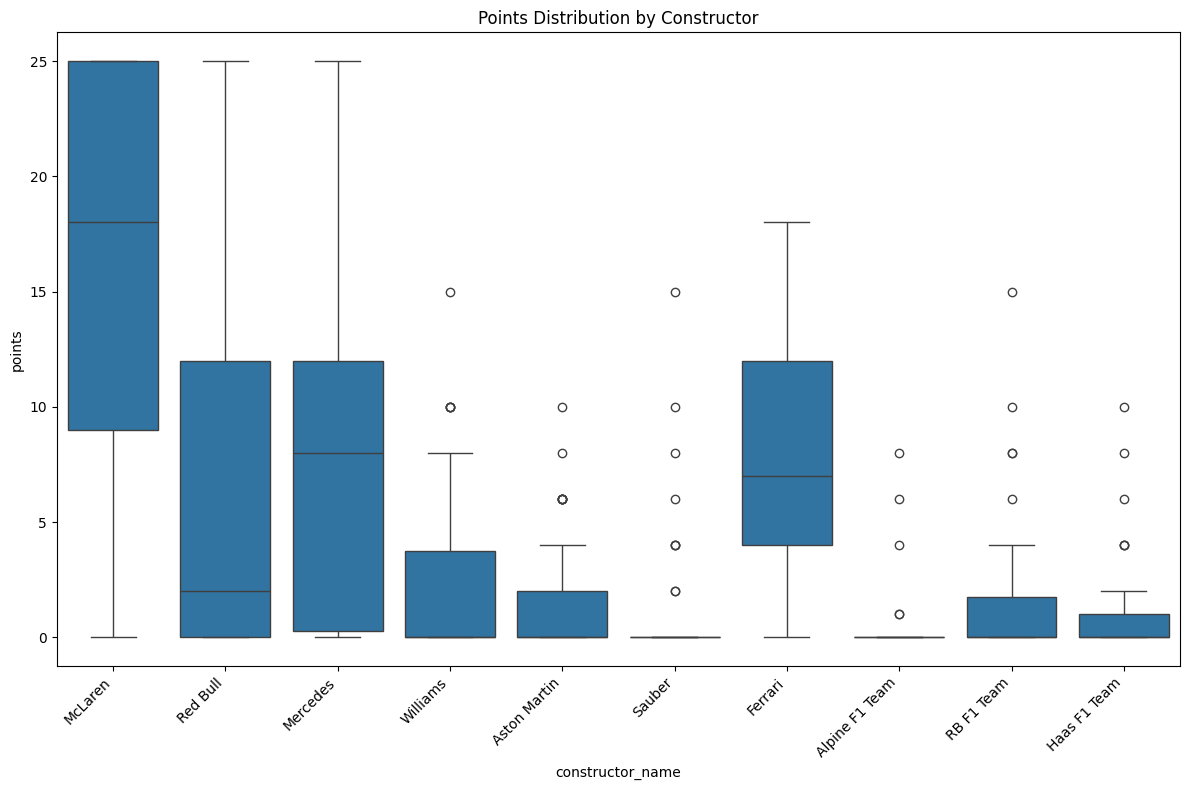

In [111]:
plt.figure(figsize=(12, 8))
sns.boxplot(x='constructor_name', y='points', data=df)
plt.title('Points Distribution by Constructor')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [112]:
winners_df = df[df['final_position'] == 1]
wins_per_circuit_driver = winners_df.groupby(['circuit_name', 'driver_name']).size().reset_index(name='win_count')




In [113]:

most_wins_by_driver_on_circuit = wins_per_circuit_driver.sort_values('win_count', ascending=False)\
    .groupby('circuit_name').first().reset_index()

# Show top 10 for preview
most_wins_by_driver_on_circuit.head()

,circuit_name,driver_name,win_count
0,Albert Park Grand Prix Circuit,Lando Norris,1
1,Autodromo Enzo e Dino Ferrari,Max Verstappen,1
2,Autodromo Nazionale di Monza,Max Verstappen,1
3,Bahrain International Circuit,Oscar Piastri,1
4,Baku City Circuit,Max Verstappen,1


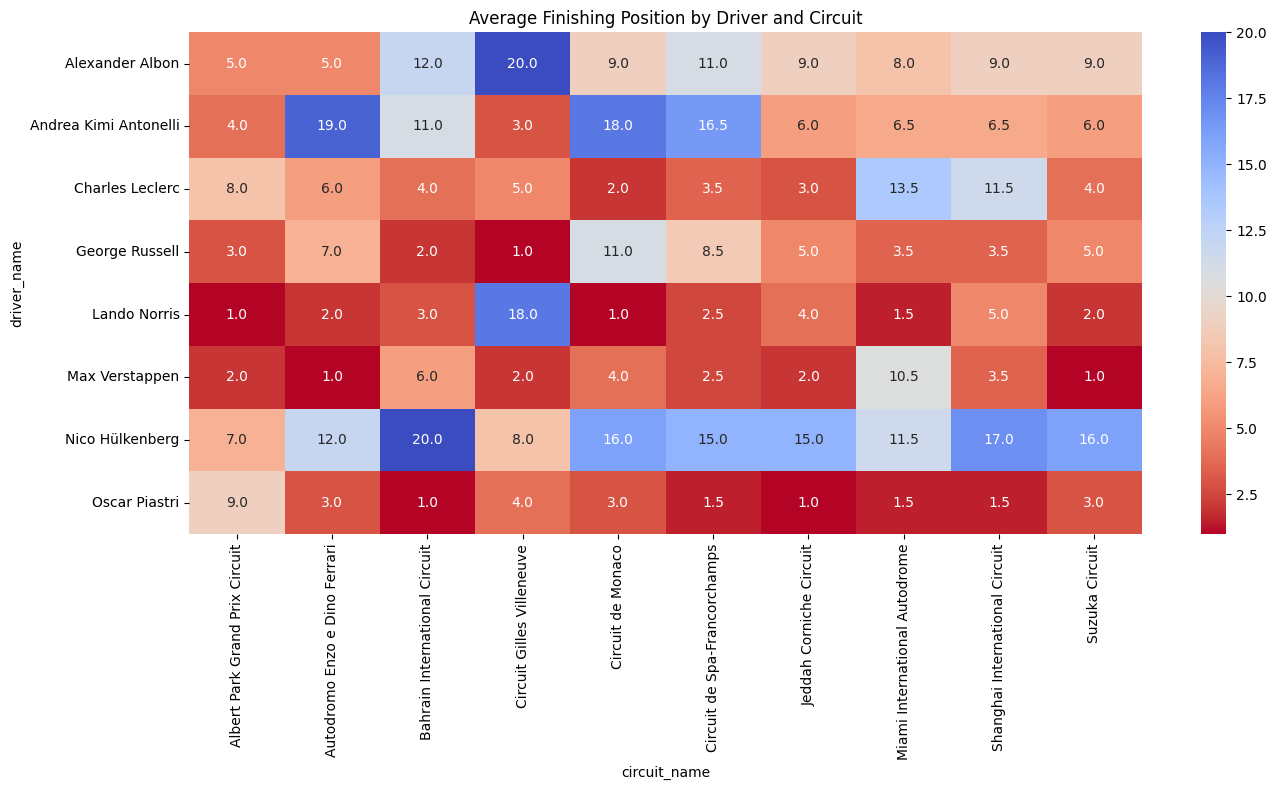

In [114]:
top_circuits = df['circuit_name'].value_counts().nlargest(10).index
top_drivers = df['driver_name'].value_counts().nlargest(8).index

circuit_perf = pd.pivot_table(
    df[df['circuit_name'].isin(top_circuits) & df['driver_name'].isin(top_drivers)],
    values='final_position',
    index='driver_name',
    columns='circuit_name',
    aggfunc='mean'
)

plt.figure(figsize=(14, 8))
sns.heatmap(circuit_perf, annot=True, cmap='coolwarm_r', fmt='.1f')
plt.title('Average Finishing Position by Driver and Circuit')
plt.tight_layout()
plt.show()

In [115]:
dnf_status = df[df['status'] !='Finished']['status'].value_counts().nlargest(10)
dnf_status

status
Lapped           72
Retired          40
Disqualified      4
Did not start     3
Name: count, dtype: int64

([0, 1, 2, 3],
 [Text(0, 0, 'Lapped'),
  Text(1, 0, 'Retired'),
  Text(2, 0, 'Disqualified'),
  Text(3, 0, 'Did not start')])

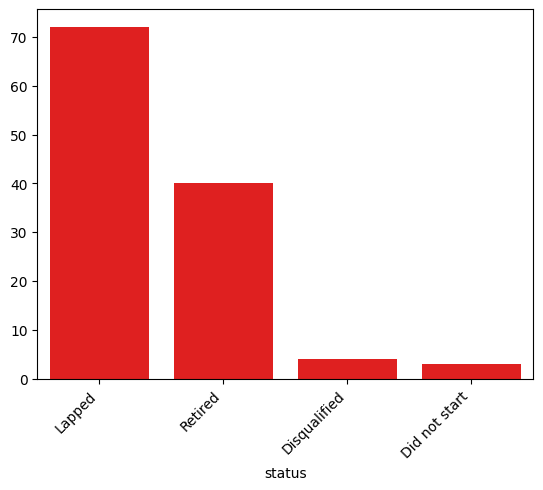

In [116]:
sns.barplot(x=dnf_status.index, y=dnf_status.values, color='red')
plt.xticks(rotation=45, ha='right')

C:\Users\Divyansh\AppData\Local\Temp\ipykernel_28188\3186569103.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='final_position', y='constructor_name', data=grid_final_corr, palette='viridis')


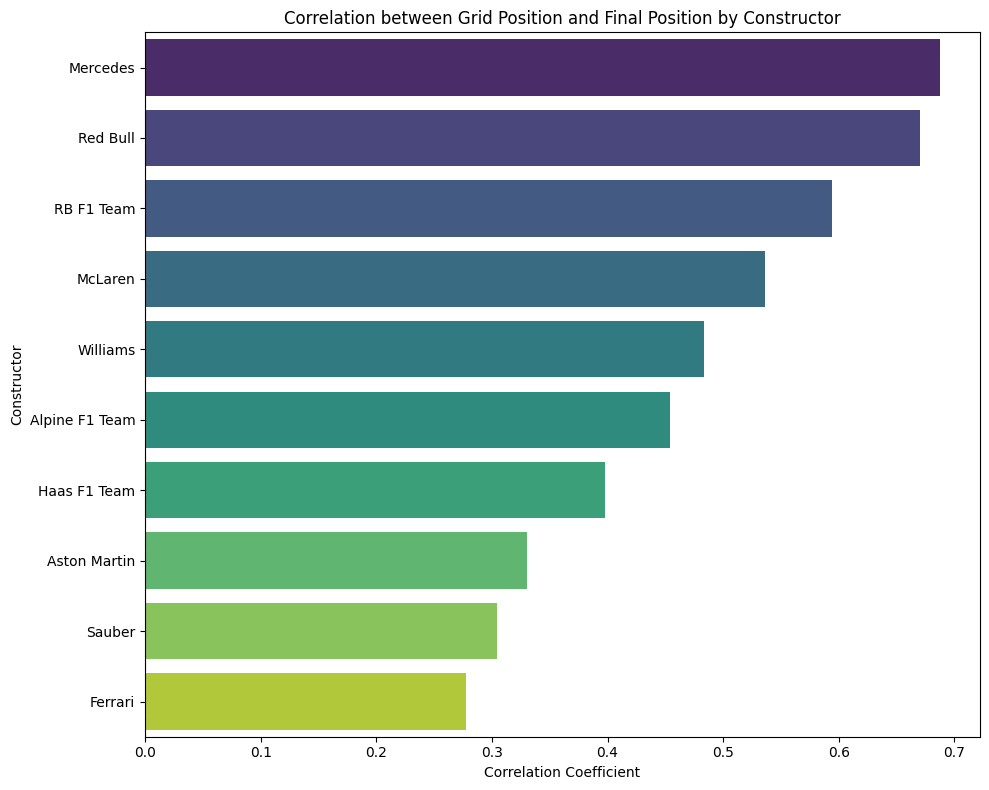

In [117]:

plt.figure(figsize=(10, 8))
grid_final_corr = df.groupby('constructor_name')[['grid_position', 'final_position']].corr().iloc[0::2, 1].reset_index()
grid_final_corr = grid_final_corr.sort_values('final_position', ascending=False)

sns.barplot(x='final_position', y='constructor_name', data=grid_final_corr, palette='viridis')
plt.title('Correlation between Grid Position and Final Position by Constructor')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Constructor')
plt.axvline(x=0, color='r', linestyle='--')
plt.tight_layout()
plt.show()

C:\Users\Divyansh\AppData\Local\Temp\ipykernel_28188\852354508.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=standings, x=col_team, y=col_points,


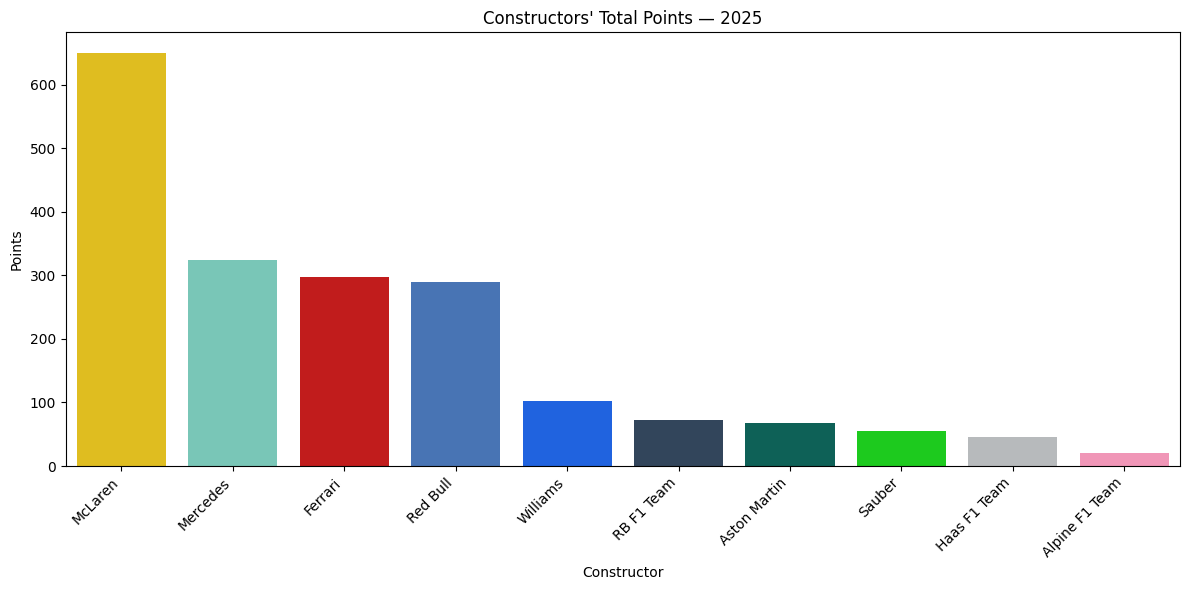

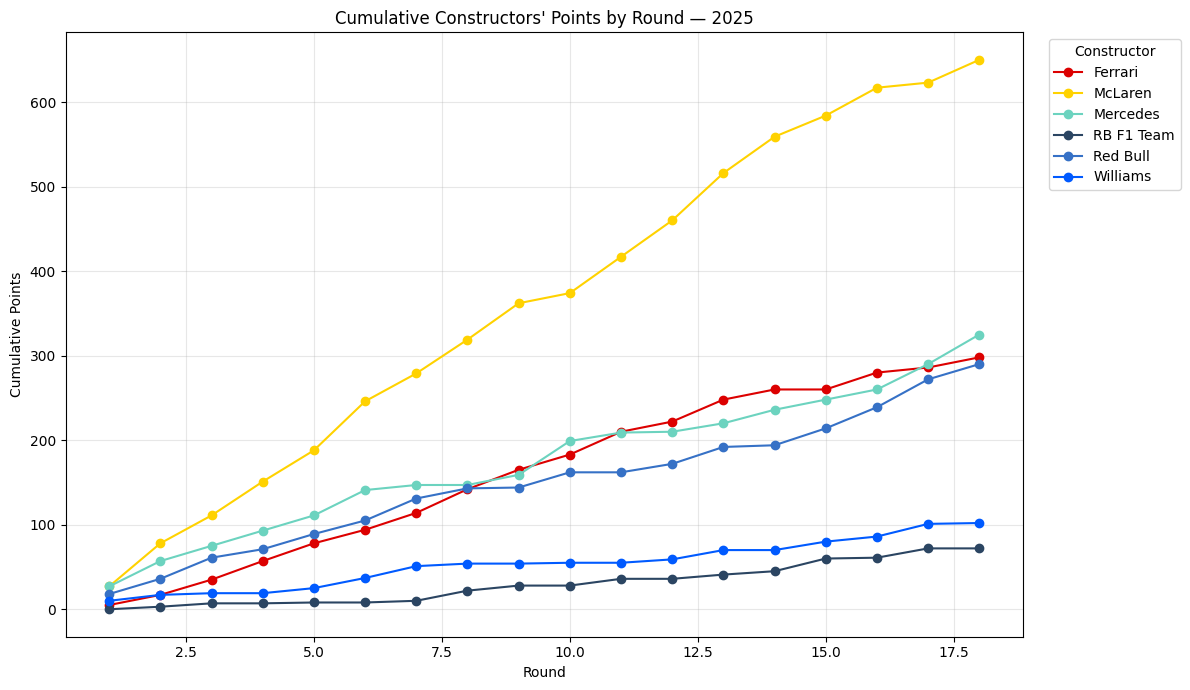

,constructor_name,points
4,McLaren,650.0
5,Mercedes,325.0
2,Ferrari,298.0
7,Red Bull,290.0
9,Williams,102.0
6,RB F1 Team,72.0
1,Aston Martin,68.0
8,Sauber,55.0
3,Haas F1 Team,46.0
0,Alpine F1 Team,20.0


In [118]:

# Traditional team colors 
team_colors = {
    'Red Bull': '#3671C6',
    'Ferrari': '#DC0000',
    'Mercedes': '#6CD3BF',
    'McLaren': '#FFD200',     
    'Aston Martin': '#006F62',
    'Alpine F1 Team': '#FF87B3',
    'Williams': '#005AFF',
    'Haas F1 Team': '#B6BABD',
    'RB F1 Team': '#2B4562',
    'Visa Cash App RB': '#2B4562',
    'AlphaTauri': '#2B4562',
    'Sauber': '#00E701',
    'Stake F1 Team Kick Sauber': '#00E701',
    'Renault': '#FFF500',
    'Racing Point': '#F596C8',
    'Alfa Romeo': '#900000',
}

# Robust column detection
cand = lambda cols: next((c for c in cols if c in df.columns), None)
col_team   = cand(['constructor_name', 'team', 'constructor', 'constructorId'])
col_points = cand(['points', 'Points'])
col_season = cand(['season_year', 'season', 'Year'])
col_round  = cand(['race_round_number', 'round', 'Round'])

if col_team is None or col_points is None:
    raise KeyError('Required columns not found: constructor/team and points')

work = df.copy()
work[col_points] = pd.to_numeric(work[col_points], errors='coerce').fillna(0.0)

# Filter to 2025 if season exists, else use all
if col_season is not None and (work[col_season] == 2025).any():
    work = work[work[col_season] == 2025].copy()
    title_season = '2025'
else:
    title_season = 'All Seasons (season column missing)'

# 1) Total points by constructor (bar chart)
standings = (
    work.groupby(col_team, as_index=False)[col_points]
        .sum()
        .sort_values(col_points, ascending=False)
)

# Build color list aligned with bar order (fallback gray for unknown)
bar_colors = [team_colors.get(t, '#999999') for t in standings[col_team]]

plt.figure(figsize=(12, 6))
sns.barplot(data=standings, x=col_team, y=col_points, 
            palette=bar_colors, 
            order=standings[col_team])  # ← Add this

plt.title(f"Constructors' Total Points — {title_season}")
plt.xlabel('Constructor')
plt.ylabel('Points')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 2) Cumulative points per round for top constructors (line chart)
if col_round is not None and col_season is not None and not work.empty:
    # aggregate race points per round per constructor
    per_round = (
        work.groupby([col_season, col_round, col_team], as_index=False)[col_points].sum()
    )

    # pick top N by total points to declutter
    totals = per_round.groupby(col_team, as_index=False)[col_points].sum().sort_values(col_points, ascending=False)
    top = totals[col_team].head(6).tolist()
    per_round_top = per_round[per_round[col_team].isin(top)].copy()

    # pivot and cumulative sum by round
    pivot = per_round_top.pivot_table(index=col_round, columns=col_team, values=col_points, aggfunc='sum').sort_index()
    cum = pivot.cumsum()

    plt.figure(figsize=(12, 7))
    for team in cum.columns:
        plt.plot(cum.index, cum[team], marker='o', label=team, color=team_colors.get(team, '#999999'))
    plt.title(f"Cumulative Constructors' Points by Round — {title_season}")
    plt.xlabel('Round')
    plt.ylabel('Cumulative Points')
    plt.grid(True, alpha=0.3)
    plt.legend(title='Constructor', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print('Round/Season columns not found; skipped cumulative-by-round chart.')

# Display table snapshot
standings